# Dataset -> IBM Research Claim Stance

### Task: Stance detection

## Load Dataset

In [2]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("ibm-research/claim_stance", "claim_stance")

df = ds["train"].to_pandas()

df.head()

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hp\.cache\huggingface\hub\datasets--ibm-research--claim_stance. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 1355/1355 [00:00<00:00, 59703.36 examples/s]


,topicId,split,topicText,topicTarget,topicSentiment,claims.claimId,claims.stance,claims.claimCorrectedText,claims.claimOriginalText,claims.Compatible,claims.claimTarget.text,claims.claimTarget.span.start,claims.claimTarget.span.end,claims.claimSentiment,claims.targetsRelation
0,441,train,This house believes that open primaries are th...,open primaries,1,202105,CON,A single election in which the party nominee i...,A single election in which the party nominee i...,yes,A single election in which the party nominee i...,0.0,76.0,-1.0,1.0
1,441,train,This house believes that open primaries are th...,open primaries,1,202106,CON,A party's basic function is to choose its own ...,"a party's ""basic function"" to choose its own l...",no,None,NaN,NaN,NaN,NaN
2,441,train,This house believes that open primaries are th...,open primaries,1,209686,PRO,The open primary can be seen as good for voter...,The open primary could be seen as good for vot...,yes,The open primary,0.0,16.0,1.0,1.0
3,441,train,This house believes that open primaries are th...,open primaries,1,209687,PRO,the open primary allows nonpartisan or indepen...,the open primary allows nonpartisan or indepen...,yes,the open primary,0.0,16.0,1.0,1.0
4,441,train,This house believes that open primaries are th...,open primaries,1,209688,PRO,If nonpartisan or independent voters are allow...,If these voters are allowed to help select the...,yes,nonpartisan or independent voters,3.0,36.0,1.0,1.0


In [3]:
## Shape of dataset

df.shape

(1039, 15)

### Inference:

The dataset have 1039 rows and 15 columns.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1039 entries, 0 to 1038
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   topicId                        1039 non-null   int64  
 1   split                          1039 non-null   object 
 2   topicText                      1039 non-null   object 
 3   topicTarget                    1039 non-null   object 
 4   topicSentiment                 1039 non-null   int64  
 5   claims.claimId                 1039 non-null   int64  
 6   claims.stance                  1039 non-null   object 
 7   claims.claimCorrectedText      1039 non-null   object 
 8   claims.claimOriginalText       1039 non-null   object 
 9   claims.Compatible              1039 non-null   object 
 10  claims.claimTarget.text        974 non-null    object 
 11  claims.claimTarget.span.start  974 non-null    float64
 12  claims.claimTarget.span.end    974 non-null    f

### Inference:

The dataset has 8 text based columns and 7 numeric columns.

In [5]:
df.columns

Index(['topicId', 'split', 'topicText', 'topicTarget', 'topicSentiment',
       'claims.claimId', 'claims.stance', 'claims.claimCorrectedText',
       'claims.claimOriginalText', 'claims.Compatible',
       'claims.claimTarget.text', 'claims.claimTarget.span.start',
       'claims.claimTarget.span.end', 'claims.claimSentiment',
       'claims.targetsRelation'],
      dtype='object')

| Column                            | Description                                                       |
| --------------------------------- | ----------------------------------------------------------------- |
| **topicId**                       | Unique identifier for each debate topic.                          |
| **split**                         | Dataset partition used for training, validation, or testing.      |
| **topicText**                     | Text description of the debate topic.                             |
| **topicTarget**                   | Specific entity or subject being debated within the topic.        |
| **topicSentiment**                | Sentiment orientation of the topic toward the target.             |
| **claims.claimId**                | Unique identifier for each claim in the dataset.                  |
| **claims.stance**                 | Stance of the claim toward the topic (e.g., pro or con).          |
| **claims.claimCorrectedText**     | Cleaned or corrected version of the claim text.                   |
| **claims.claimOriginalText**      | Original claim text before correction.                            |
| **claims.Compatible**             | Indicates whether the claim is compatible with the topic context. |
| **claims.claimTarget.text**       | Text span representing the target entity within the claim.        |
| **claims.claimTarget.span.start** | Starting position of the claim target in the text.                |
| **claims.claimTarget.span.end**   | Ending position of the claim target in the text.                  |
| **claims.claimSentiment**         | Sentiment expressed in the claim toward the target.               |
| **claims.targetsRelation**        | Relationship between the claim target and the topic target.       |

In [6]:
df.nunique()

topicId                            25
split                               1
topicText                          25
topicTarget                        25
topicSentiment                      2
claims.claimId                   1039
claims.stance                       2
claims.claimCorrectedText        1034
claims.claimOriginalText         1033
claims.Compatible                   2
claims.claimTarget.text           718
claims.claimTarget.span.start      84
claims.claimTarget.span.end       128
claims.claimSentiment               2
claims.targetsRelation              2
dtype: int64

**Inference:**

The dataset contains **25 unique debate topics and 1,039 distinct claims**, indicating a moderate-sized stance detection dataset. Most claim-related fields show high uniqueness, reflecting diverse claim content, while several features such as **stance, compatibility, sentiment, and target relations are binary**, representing opposing viewpoints and relationships within the debate context.

In [7]:
### Missing values check

df.isnull().sum()

topicId                           0
split                             0
topicText                         0
topicTarget                       0
topicSentiment                    0
claims.claimId                    0
claims.stance                     0
claims.claimCorrectedText         0
claims.claimOriginalText          0
claims.Compatible                 0
claims.claimTarget.text          65
claims.claimTarget.span.start    65
claims.claimTarget.span.end      65
claims.claimSentiment            65
claims.targetsRelation           65
dtype: int64

**Inference:**

Most columns contain **no missing values**, indicating well-structured annotations. However, about **65 entries lack target-related information** (target text, span positions, sentiment, and relation), suggesting that some claims do not explicitly reference a specific target entity.


## Topic Distribution

In [9]:
df["topicText"].value_counts()

topicText
This house would unleash the free market                                                                               182
This house would build hydroelectric dams                                                                              110
This house believes that Israel's 2008-2009 military operations against Gaza were justified                             84
This house would promote democratization                                                                                76
This house believes that advertising is harmful                                                                         55
This house believes that it is sometimes right for the government to restrict freedom of speech                         55
This house believes that the Catholic Church is justified in forbidding the use of barrier methods of contraception     50
This house believes governments should choose open source software in order to encourage its use                        48
This h

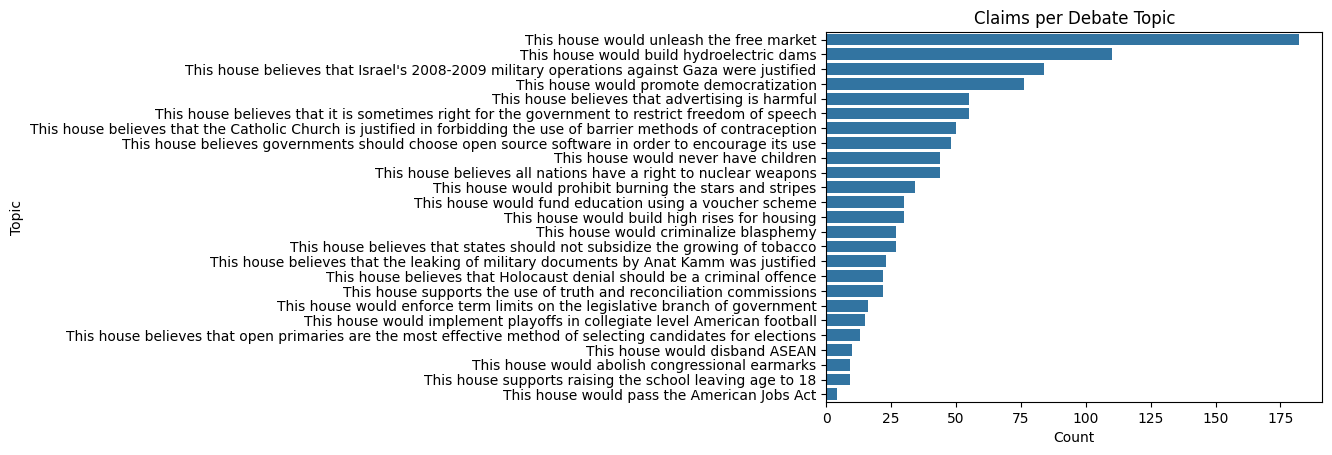

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    y=df["topicText"],
    order=df["topicText"].value_counts().index
)

plt.title("Claims per Debate Topic")
plt.xlabel("Count")
plt.ylabel("Topic")
plt.show()

### Inference:

Claims are distributed across multiple debate topics, with some topics having more arguments than others.

## Topic Sentiment Distribution

In [11]:
df["topicSentiment"].value_counts()

topicSentiment
 1    706
-1    333
Name: count, dtype: int64

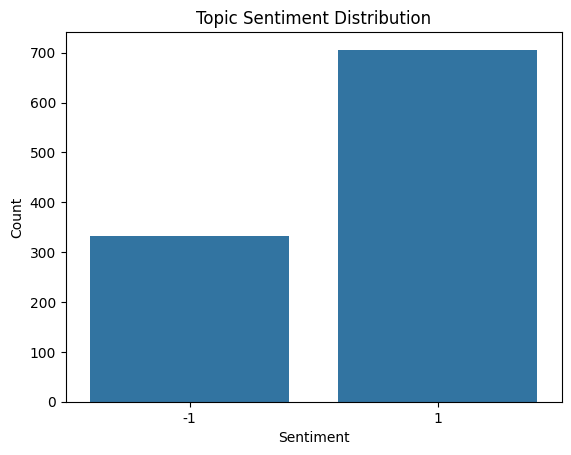

In [12]:
sns.countplot(x=df["topicSentiment"])

plt.title("Topic Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

**Inference:**

The topic sentiment distribution shows a **higher number of positive sentiment topics (706) compared to negative sentiment topics (333)**, indicating a noticeable imbalance toward positively framed debate topics in the dataset.

## Claim Stance Distribution

In [13]:
df["claims.stance"].value_counts()

claims.stance
PRO    625
CON    414
Name: count, dtype: int64

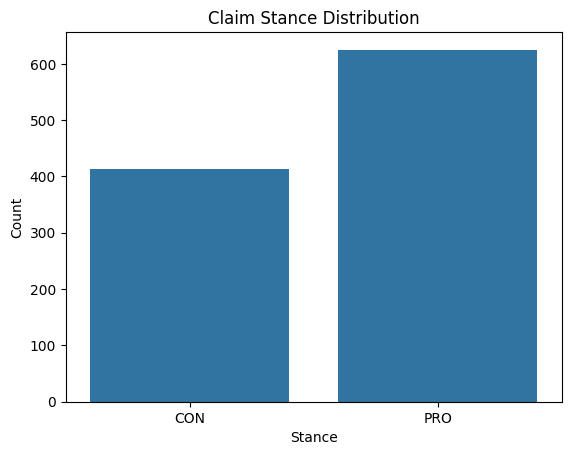

In [14]:
sns.countplot(x=df["claims.stance"])

plt.title("Claim Stance Distribution")
plt.xlabel("Stance")
plt.ylabel("Count")
plt.show()

### Inference:

The dataset contains two stance labels representing opposing viewpoints toward the debate topic.

## Claim Compatibility

In [15]:
df["claims.Compatible"].value_counts()

claims.Compatible
yes    974
no      65
Name: count, dtype: int64

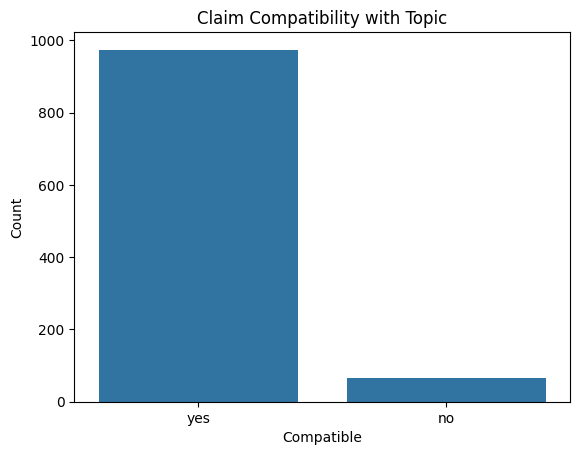

In [16]:
sns.countplot(x=df["claims.Compatible"])

plt.title("Claim Compatibility with Topic")
plt.xlabel("Compatible")
plt.ylabel("Count")
plt.show()

**Inference:**

The majority of claims (**974**) are marked as compatible with the topic, while only **65 claims are incompatible**, indicating a strong imbalance where most claims are contextually aligned with their associated debate topics.


## Claim Sentiment

In [17]:
df["claims.claimSentiment"].value_counts()

claims.claimSentiment
-1.0    519
 1.0    455
Name: count, dtype: int64

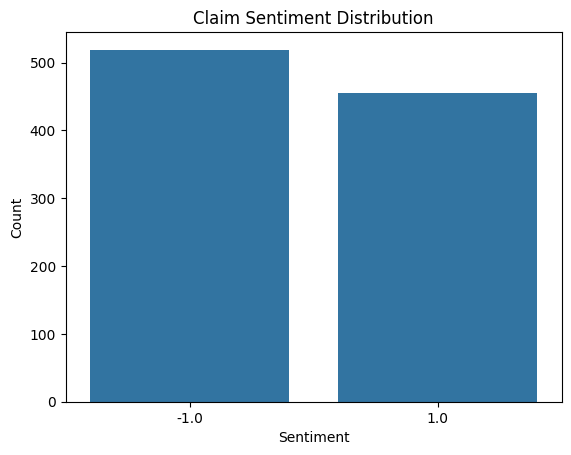

In [18]:
sns.countplot(x=df["claims.claimSentiment"])

plt.title("Claim Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

**Inference:**

The claim sentiment distribution is relatively balanced, with **519 negative and 455 positive claims**, indicating that the dataset contains comparable representation of opposing sentiments in argumentative claims.


## Target Relation Distribution

In [19]:
df["claims.targetsRelation"].value_counts()

claims.targetsRelation
 1.0    784
-1.0    190
Name: count, dtype: int64

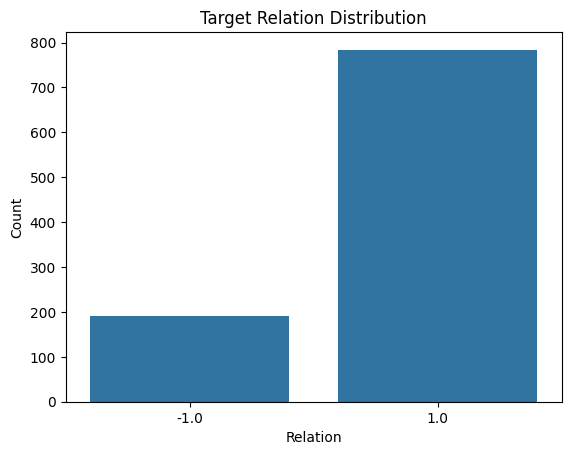

In [20]:
sns.countplot(x=df["claims.targetsRelation"])

plt.title("Target Relation Distribution")
plt.xlabel("Relation")
plt.ylabel("Count")
plt.show()

**Inference:**

The target relation distribution shows a noticeable imbalance, with **784 positive relations compared to 190 negative relations**, indicating that most claims have a supportive relationship with the topic target rather than an opposing one.

## Claim Length Analysis

In [21]:
df["char_length"] = df["claims.claimCorrectedText"].apply(len)

df["word_count"] = df["claims.claimCorrectedText"].apply(lambda x: len(x.split()))

df["word_count"].describe()

count    1039.000000
mean       12.669875
std         5.563763
min         3.000000
25%         9.000000
50%        12.000000
75%        15.000000
max        35.000000
Name: word_count, dtype: float64

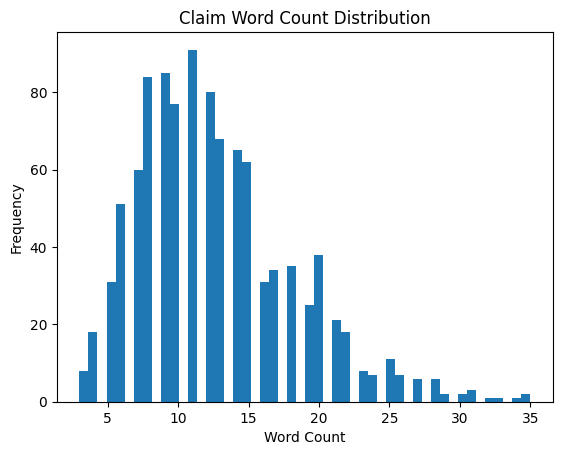

In [22]:
plt.hist(df["word_count"], bins=50)

plt.title("Claim Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

**Inference:**

The claims are generally **short textual statements**, with an average length of about **13 words**. Most claims fall between **9 and 15 words**, indicating concise argumentative expressions suitable for NLP classification tasks.


## Claim Length vs Stance

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


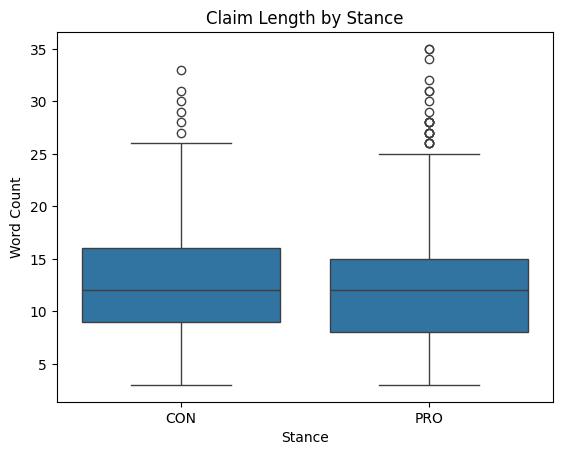

In [23]:
sns.boxplot(
    x=df["claims.stance"],
    y=df["word_count"]
)

plt.title("Claim Length by Stance")
plt.xlabel("Stance")
plt.ylabel("Word Count")
plt.show()

**Inference:**

The distribution of claim lengths for both **PRO and CON stances is very similar**, with comparable median word counts and spread. This suggests that claim length does not significantly differ based on stance orientation.


## Vocabulary Analysis

In [24]:
from collections import Counter

all_words = " ".join(df["claims.claimCorrectedText"].astype(str)).split()

vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))
print(vocab.most_common(20))

Vocabulary size: 3140
[('the', 703), ('of', 598), ('to', 486), ('and', 304), ('is', 290), ('a', 280), ('in', 204), ('be', 141), ('for', 117), ('are', 114), ('The', 98), ('can', 97), ('by', 83), ('as', 76), ('free', 75), ('not', 71), ('more', 66), ('have', 63), ('or', 62), ('that', 58)]


**Inference:**

The dataset contains a **vocabulary of 3,140 unique words**, indicating moderate lexical diversity. The most frequent words are common stopwords (e.g., *the, of, to, and*), suggesting that further text preprocessing such as stopword removal may help focus on more meaningful terms during modeling.


## Clean Vocabulary

In [25]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

clean_words = [
    w for w in all_words
    if w.lower() not in stop_words and w.isalpha()
]

print("Clean vocabulary size:", len(set(clean_words)))

Clean vocabulary size: 2653


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Inference:**

After removing stopwords and non-alphabetic tokens, the vocabulary size reduces to **2,653 unique words**, indicating that the dataset still retains substantial lexical diversity relevant for modeling argumentative claims.


## Example Claims

In [26]:
for i in range(5):
    print("Topic:", df["topicText"].iloc[i])
    print("Claim:", df["claims.claimCorrectedText"].iloc[i])
    print("Stance:", df["claims.stance"].iloc[i])
    print()

Topic: This house believes that open primaries are the most effective method of selecting candidates for elections
Claim: A single election in which the party nominee is selected by nonparty members could be enough to destroy the party
Stance: CON

Topic: This house believes that open primaries are the most effective method of selecting candidates for elections
Claim: A party's basic function is to choose its own leaders
Stance: CON

Topic: This house believes that open primaries are the most effective method of selecting candidates for elections
Claim: The open primary can be seen as good for voter participation
Stance: PRO

Topic: This house believes that open primaries are the most effective method of selecting candidates for elections
Claim: the open primary allows nonpartisan or independent voters to participate in the nominating process
Stance: PRO

Topic: This house believes that open primaries are the most effective method of selecting candidates for elections
Claim: If nonpart

# Key Insights

### Key Insights

**1. Topic Diversity**

The dataset contains **25 debate topics with over 1,000 argumentative claims**, providing diverse contexts for stance detection.

---

**2. Stance Distribution**

Claims are labeled with **two opposing stances (PRO and CON)**, allowing supervised modeling of stance classification tasks.

---

**3. Topic Sentiment Imbalance**

Positive topic sentiments occur more frequently than negative ones, indicating a moderate imbalance in topic framing.

---

**4. Claim Compatibility**

The majority of claims are **compatible with their associated topics**, suggesting that most arguments are contextually aligned with the debate subject.

---

**5. Claim Sentiment Balance**

Positive and negative claim sentiments are relatively balanced, providing good representation of opposing viewpoints.

---

**6. Target Relation Patterns**

Most claims have a **supportive relationship with the topic target**, while fewer represent opposing relations.

---

**7. Claim Length Characteristics**

Claims are generally **short textual statements**, averaging around **13 words**, which is typical for argumentative claims.

---

**8. Stance vs Length**

The length distributions of **PRO and CON claims are very similar**, suggesting that stance orientation does not significantly affect claim length.

---

**9. Vocabulary Diversity**

After preprocessing, the dataset contains **over 2,600 unique meaningful tokens**, indicating moderate lexical diversity in argumentative expressions.